**Data Collection and Processes**

In [3]:
import pandas as pd
# Load the dataset
df = pd.read_csv('train.csv')
# Check the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Get info about columns, data types, and non-null counts
df.info()
# Check how many missing values each column has
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Exploring Data**

In [5]:
# Check overall survival rate
df['Survived'].value_counts()
# Survival rate by gender
df.groupby('Sex')['Survived'].mean()
# Survival rate by passenger class
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


**Handling Missing Values**

In [6]:
# Fill missing Age with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)
# Fill missing Embarked with the most common value (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Drop Cabin column - too many missing values to be useful
df.drop('Cabin', axis=1, inplace=True)
# Verify no more missing values
df.isnull().sum()

/tmp/ipykernel_1846/2772943906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1846/2772943906.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Droping Columns (not required)**

In [7]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [20]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


**Encoding Categorical Columns**

In [8]:
# Convert Sex to numbers: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Convert Embarked to numbers using one-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


**Splitting, Training and Test Data**

In [9]:
from sklearn.model_selection import train_test_split

# X = all the features (input), y = what we want to predict
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (712, 8)
Test set: (179, 8)


In [27]:
print (X)

     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         3    0  22.0      1      0   7.2500       False        True
1         1    1  38.0      1      0  71.2833       False       False
2         3    1  26.0      0      0   7.9250       False        True
3         1    1  35.0      1      0  53.1000       False        True
4         3    0  35.0      0      0   8.0500       False        True
..      ...  ...   ...    ...    ...      ...         ...         ...
886       2    0  27.0      0      0  13.0000       False        True
887       1    1  19.0      0      0  30.0000       False        True
888       3    1  28.0      1      2  23.4500       False        True
889       1    0  26.0      0      0  30.0000       False       False
890       3    0  32.0      0      0   7.7500        True       False

[891 rows x 8 columns]


In [28]:
print (y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


**Logistic Regression**

In [10]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train it on the training data
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


**Evaluating Model**

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Feature Importance**

In [12]:
import pandas as pd

# Get feature importance from logistic regression coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance)

      Feature  Coefficient
1         Sex     2.591222
0      Pclass    -0.938047
7  Embarked_S    -0.400561
3       SibSp    -0.295062
6  Embarked_Q    -0.111981
4       Parch    -0.107848
2         Age    -0.030574
5        Fare     0.002576


**Building Correlation**

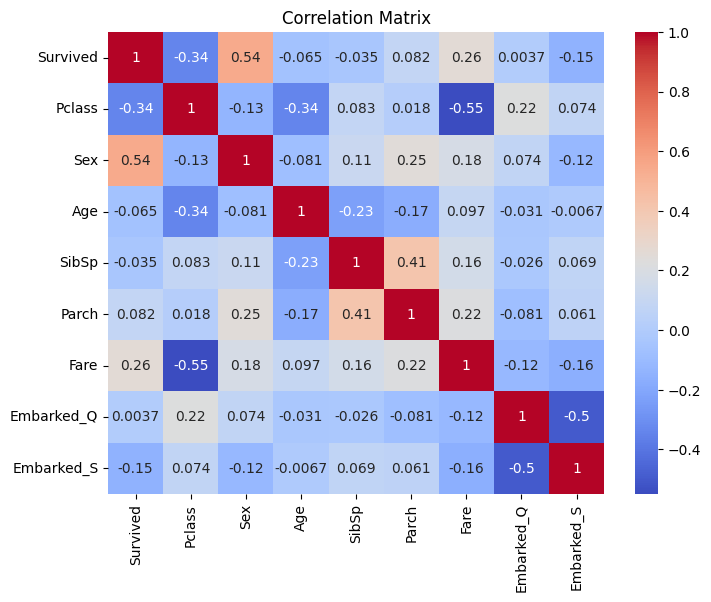

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Visualization**

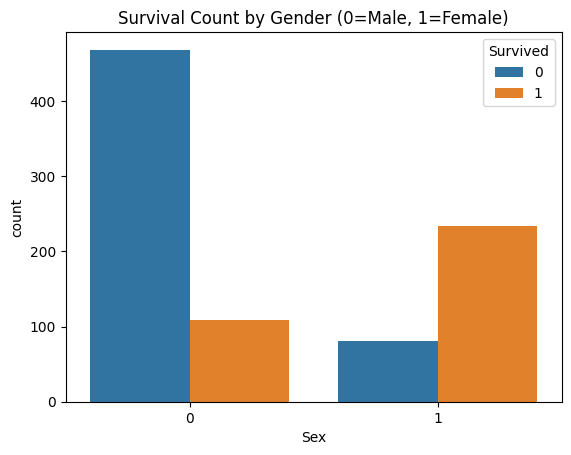

In [14]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender (0=Male, 1=Female)')
plt.show()

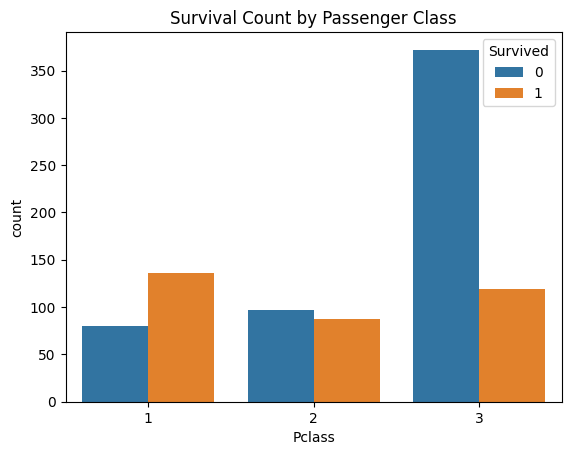

In [15]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.show()

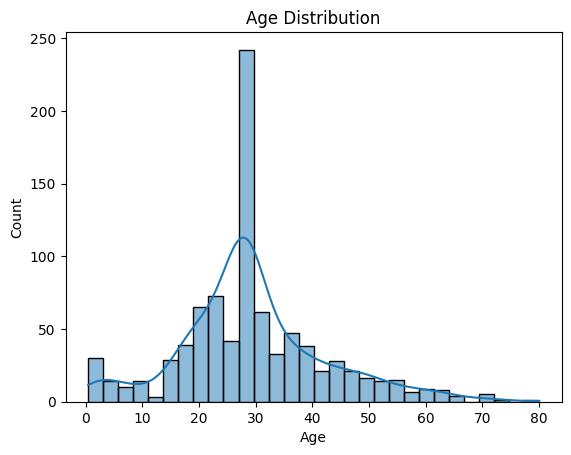

In [16]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

**Graphic User Interface (GUI)**

In [17]:
!pip install gradio -q

In [18]:
import gradio as gr

def predict_survival(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked):
    # Convert inputs to match training format
    sex_val = 1 if Sex == "Female" else 0
    embarked_Q = 1 if Embarked == "Q" else 0
    embarked_S = 1 if Embarked == "S" else 0

    # Create input array in the same column order as X_train
    input_data = [[Pclass, sex_val, Age, SibSp, Parch, Fare, embarked_Q, embarked_S]]

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    result = "Survived" if prediction == 1 else "Did Not Survive"
    return f"{result} (Survival Probability: {probability:.2%})"

# Build the interface
demo = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Number(label="Pclass (1, 2, or 3)", value=3),
        gr.Radio(["Male", "Female"], label="Sex"),
        gr.Number(label="Age", value=25),
        gr.Number(label="SibSp (siblings/spouses aboard)", value=0),
        gr.Number(label="Parch (parents/children aboard)", value=0),
        gr.Number(label="Fare", value=30),
        gr.Radio(["S", "C", "Q"], label="Embarked")
    ],
    outputs="text",
    title="Titanic Survival Predictor",
    description="Enter passenger details to predict survival chance"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e53e84e1e6756a1e1b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
